## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [1]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

In [2]:
import os
import requests
import json
from urllib.parse import urlparse, parse_qs

filename = "modules.ipynb"

github_raw_url = "https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/hw08_nn_from_scratch/modules.ipynb"

if not os.path.exists(filename):
    print(f"'{filename}' не найден. Скачиваем с GitHub...")
    response = requests.get(github_raw_url)
    response.raise_for_status()  # выбросит исключение при HTTP-ошибке

    with open(filename, "wb") as f:
        f.write(response.content)

    print(f"Файл успешно скачан и сохранён как '{filename}'")
else:
    print(f"'{filename}' уже существует — скачивание не требуется.")

if os.path.exists(filename):
    py_filename = "modules.py"
    print(f"Конвертируем '{filename}' в '{py_filename}'...")

    with open(filename, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    with open(py_filename, 'w', encoding='utf-8') as f:
        for cell in nb['cells']:
            if cell['cell_type'] == 'code':
                for line in cell['source']:
                    f.write(line)
                f.write('\n')

    print(f"'{py_filename}' успешно создан!")

'modules.ipynb' не найден. Скачиваем с GitHub...
Файл успешно скачан и сохранён как 'modules.ipynb'
Конвертируем 'modules.ipynb' в 'modules.py'...
'modules.py' успешно создан!


In [3]:
# (re-)load layers
# %run modules.ipynb

import sys
import importlib
import os
import shutil

# хочу что modules подгружался с диска каждый раз заново
if 'modules' in sys.modules:
    del sys.modules['modules']
# удалить кеш компиляции
if os.path.exists('__pycache__'):
    shutil.rmtree('__pycache__')

from modules import *


/content/modules.py:396: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

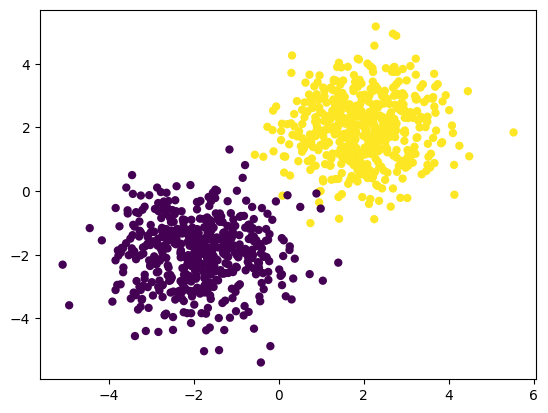

In [4]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging.

In [5]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then

# net = Sequential()
# net.add(Linear(2, 4))
# net.add(ReLU())
# net.add(Linear(4, 2))
# net.add(LogSoftMax())

Linear 2 -> 2
LogSoftMax



Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [6]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [7]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

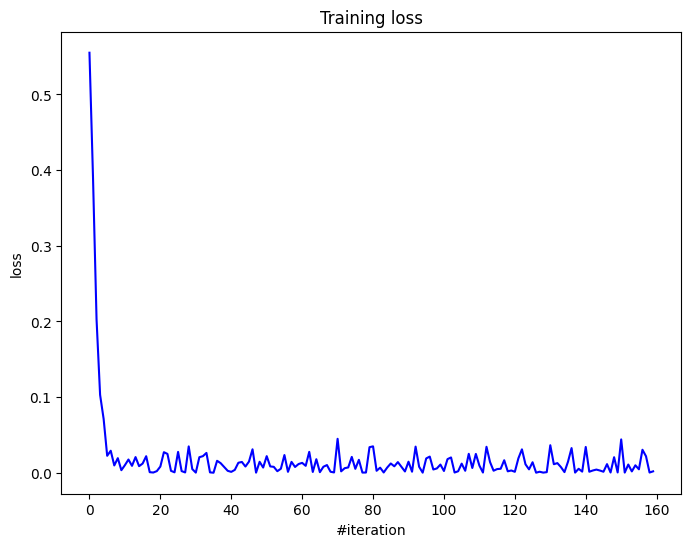

Current loss: 0.002012


In [8]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        net.zeroGradParameters()

        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)

        # Update weights
        sgd_momentum(net.getParameters(),
                     net.getGradParameters(),
                     optimizer_config,
                     optimizer_state)

        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss)

# Digit classification

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [9]:
#!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc
!wget https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

--2025-12-12 19:11:11--  https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2787 (2.7K) [text/plain]
Saving to: ‘mnist.py’

mnist.py            100%[===================>]   2.72K  --.-KB/s    in 0s      

2025-12-12 19:11:11 (49.9 MB/s) - ‘mnist.py’ saved [2787/2787]



In [10]:
import sys
import importlib
import os
import shutil

# хочу что modules подгружался с диска каждый раз заново
if 'mnist' in sys.modules:
    del sys.modules['mnist']
# удалить кеш компиляции
if os.path.exists('__pycache__'):
    shutil.rmtree('__pycache__')

import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

One-hot encode the labels first.

In [11]:
# Your code goes here. ################################################

def one_hot_encode(labels, num_classes=10):
    n_samples = labels.shape[0]
    one_hot = np.zeros((n_samples, num_classes))
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot

y_train_oh = one_hot_encode(y_train)
y_val_oh = one_hot_encode(y_val)
y_test_oh = one_hot_encode(y_test)

print("y_train shape:", y_train.shape)        # (50000,)
print("y_train_oh shape:", y_train_oh.shape)  # (50000, 10)

print("y_train[0]:", y_train[0])
print("y_train_oh[0]:", y_train_oh[0])

print("перевести изображения в flatten")
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (50000, 784)
X_val_flat = X_val.reshape(X_val.shape[0], -1)        # (10000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)     # (10000, 784)

print("X_train_flat shape:", X_train_flat.shape)

y_train shape: (50000,)
y_train_oh shape: (50000, 10)
y_train[0]: 5
y_train_oh[0]: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
перевести изображения в flatten
X_train_flat shape: (50000, 784)


### <font color=brown>Что нужно сделать</font>

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5.

### <font color=brown>Сравнение функций активации </font>

In [12]:
# Your code goes here. ################################################

np.random.seed(900)

def create_network(activation_class=ReLU,
                   input_size=784,
                   hidden_size=256,
                   num_classes=10,
                   use_batchnorm=False,
                   use_dropout=False,
                   dropout_p=0.5):

    net = Sequential()

    net.add(Linear(input_size, hidden_size))
    if use_batchnorm:
        net.add(BatchNormalization(alpha=0.9))
        net.add(ChannelwiseScaling(hidden_size))
    net.add(activation_class())
    if use_dropout:
        net.add(Dropout(dropout_p))

    net.add(Linear(hidden_size, hidden_size))
    if use_batchnorm:
        net.add(BatchNormalization(alpha=0.9))
        net.add(ChannelwiseScaling(hidden_size))
    net.add(activation_class())
    if use_dropout:
        net.add(Dropout(dropout_p))

    net.add(Linear(hidden_size, num_classes))
    net.add(LogSoftMax())

    return net

def train_network(net, criterion, X_train, y_train, X_val, y_val,
                  optimizer_func, optimizer_config,
                  n_epoch=20, batch_size=128):
    """
    train, возвращает историю loss
    """
    optimizer_state = {}
    train_loss_history = []
    val_loss_history = []

    for epoch in range(n_epoch):
        net.train()
        epoch_loss = []

        for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
            net.zeroGradParameters()

            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)

            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)

            # обновить веса
            optimizer_func(net.getParameters(),
                          net.getGradParameters(),
                          optimizer_config,
                          optimizer_state)

            epoch_loss.append(loss)

        train_loss_history.append(np.mean(epoch_loss))

        # валидация
        net.evaluate()
        val_predictions = net.forward(X_val)
        val_loss = criterion.forward(val_predictions, y_val)
        val_loss_history.append(val_loss)

        print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {train_loss_history[-1]:.4f}, Val Loss: {val_loss:.4f}")

    return train_loss_history, val_loss_history



Training with ReLU
Epoch 1/30, Train Loss: 0.8255, Val Loss: 0.3091
Epoch 2/30, Train Loss: 0.2943, Val Loss: 0.2389
Epoch 3/30, Train Loss: 0.2268, Val Loss: 0.1934
Epoch 4/30, Train Loss: 0.1805, Val Loss: 0.1624
Epoch 5/30, Train Loss: 0.1479, Val Loss: 0.1329
Epoch 6/30, Train Loss: 0.1229, Val Loss: 0.1227
Epoch 7/30, Train Loss: 0.1036, Val Loss: 0.1064
Epoch 8/30, Train Loss: 0.0899, Val Loss: 0.1007
Epoch 9/30, Train Loss: 0.0777, Val Loss: 0.0970
Epoch 10/30, Train Loss: 0.0683, Val Loss: 0.0929
Epoch 11/30, Train Loss: 0.0609, Val Loss: 0.0868
Epoch 12/30, Train Loss: 0.0529, Val Loss: 0.0987
Epoch 13/30, Train Loss: 0.0484, Val Loss: 0.0868
Epoch 14/30, Train Loss: 0.0424, Val Loss: 0.0793
Epoch 15/30, Train Loss: 0.0379, Val Loss: 0.0793
Epoch 16/30, Train Loss: 0.0343, Val Loss: 0.0747
Epoch 17/30, Train Loss: 0.0300, Val Loss: 0.0750
Epoch 18/30, Train Loss: 0.0267, Val Loss: 0.0749
Epoch 19/30, Train Loss: 0.0245, Val Loss: 0.0735
Epoch 20/30, Train Loss: 0.0215, Val Lo

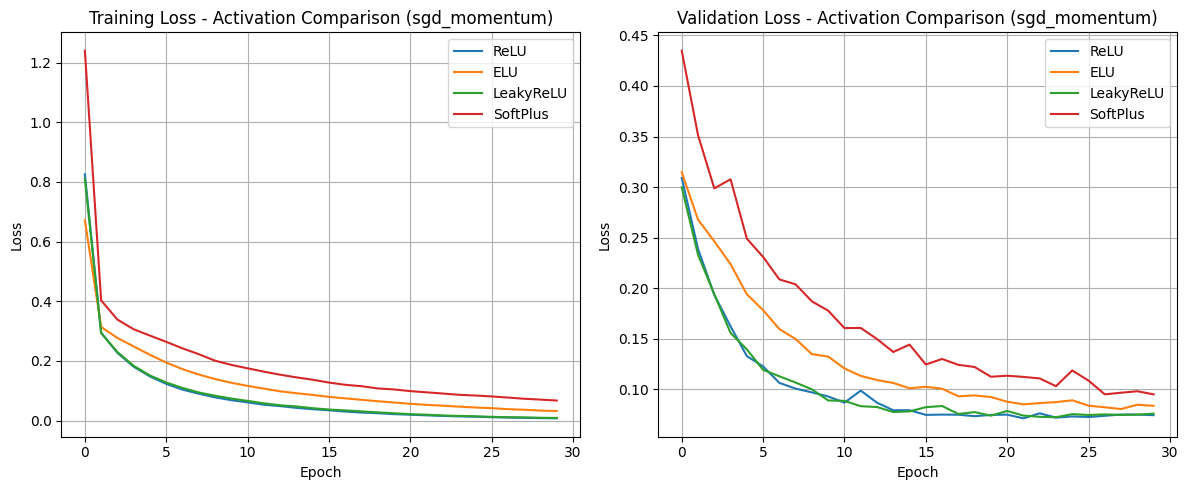

In [13]:
activations = {
    'ReLU': ReLU,
    'ELU': ELU,
    'LeakyReLU': LeakyReLU,
    'SoftPlus': SoftPlus
}

optimizer_config = {'learning_rate': 1e-2, 'momentum': 0.9}
criterion = ClassNLLCriterion()
n_epoch = 30

results = {}

for name, activation_class in activations.items():
    print(f"\n{'='*50}")
    print(f"Training with {name}")
    print('='*50)

    net = create_network(activation_class)
    train_loss, val_loss = train_network(
        net, criterion,
        X_train_flat, y_train_oh,
        X_val_flat, y_val_oh,
        sgd_momentum, optimizer_config,
        n_epoch=n_epoch
    )
    results[name] = {'train': train_loss, 'val': val_loss}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(data['train'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss - Activation Comparison (sgd_momentum)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(data['val'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss - Activation Comparison (sgd_momentum)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

<font color = darkblue>
Выводы по функциям активации:</font>

1. <font color = darkblue>ReLU и LeakyReLU показали лучшие результаты с Val Loss ~0.075.
   Они сходятся быстро и достигают низкого loss уже к 10-й эпохе.</font>

2. <font color = darkblue>ELU сходится медленнее, но показывает стабильное обучение.
   Финальный Val Loss = 0.089.</font>

3. <font color = darkblue>SoftPlus - худший результат.
   Причина: гладкая аппроксимация ReLU замедляет обучение.</font>

4. <font color = darkblue>По скорости вычислений: ReLU > LeakyReLU > ELU > SoftPlus
   (ReLU - просто max(0,x), SoftPlus требует exp и log)</font>

5. <font color = darkblue>Наблюдается лёгкое переобучение у ReLU/LeakyReLU
   (train loss << val loss), может быть с помощью BatchNormalization и Dropout что-то изменится .</font>
   


 ### <font color = brown> Сравнение c BatchNormalization и без (для ReLU) <font>



In [15]:
# Your answer goes here. ################################################
optimizer_config = {'learning_rate': 1e-2, 'momentum': 0.9}
criterion = ClassNLLCriterion()
n_epoch = 30

results_bn = {}

# Без BatchNorm
print(f"{'='*50}")
print("Training ReLU WITHOUT BatchNorm")
print('='*50)

net_no_bn = create_network(activation_class=ReLU, use_batchnorm=False)
train_loss, val_loss = train_network(
    net_no_bn, criterion,
    X_train_flat, y_train_oh,
    X_val_flat, y_val_oh,
    sgd_momentum, optimizer_config,
    n_epoch=n_epoch
)
results_bn['ReLU'] = {'train': train_loss, 'val': val_loss}

# С BatchNorm
print(f"\n{'='*50}")
print("Training ReLU WITH BatchNorm")
print('='*50)

net_with_bn = create_network(activation_class=ReLU, use_batchnorm=True)
train_loss, val_loss = train_network(
    net_with_bn, criterion,
    X_train_flat, y_train_oh,
    X_val_flat, y_val_oh,
    sgd_momentum, optimizer_config,
    n_epoch=n_epoch
)
results_bn['ReLU + BatchNorm'] = {'train': train_loss, 'val': val_loss}

Training ReLU WITHOUT BatchNorm
Epoch 1/30, Train Loss: 0.8293, Val Loss: 0.3007
Epoch 2/30, Train Loss: 0.2869, Val Loss: 0.2269
Epoch 3/30, Train Loss: 0.2208, Val Loss: 0.1827
Epoch 4/30, Train Loss: 0.1749, Val Loss: 0.1571
Epoch 5/30, Train Loss: 0.1434, Val Loss: 0.1309
Epoch 6/30, Train Loss: 0.1213, Val Loss: 0.1233
Epoch 7/30, Train Loss: 0.1016, Val Loss: 0.1077
Epoch 8/30, Train Loss: 0.0891, Val Loss: 0.1008
Epoch 9/30, Train Loss: 0.0768, Val Loss: 0.0930
Epoch 10/30, Train Loss: 0.0686, Val Loss: 0.0985
Epoch 11/30, Train Loss: 0.0590, Val Loss: 0.0863
Epoch 12/30, Train Loss: 0.0526, Val Loss: 0.0873
Epoch 13/30, Train Loss: 0.0469, Val Loss: 0.0799
Epoch 14/30, Train Loss: 0.0421, Val Loss: 0.0804
Epoch 15/30, Train Loss: 0.0376, Val Loss: 0.0800
Epoch 16/30, Train Loss: 0.0336, Val Loss: 0.0766
Epoch 17/30, Train Loss: 0.0298, Val Loss: 0.0740
Epoch 18/30, Train Loss: 0.0264, Val Loss: 0.0843
Epoch 19/30, Train Loss: 0.0240, Val Loss: 0.0756
Epoch 20/30, Train Loss: 0.

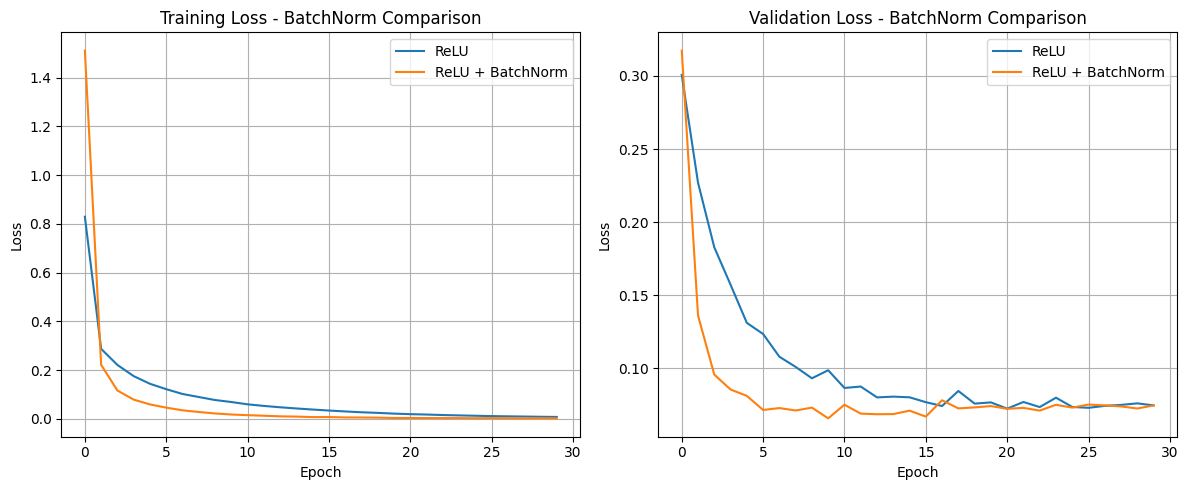

In [16]:
plt.figure(figsize=(12, 5))

# Train loss
plt.subplot(1, 2, 1)
for name, data in results_bn.items():
    plt.plot(data['train'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss - BatchNorm Comparison')
plt.legend()
plt.grid(True)

# Validation loss
plt.subplot(1, 2, 2)
for name, data in results_bn.items():
    plt.plot(data['val'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss - BatchNorm Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<font color=darkblue>BatchNorm помогает - сеть сходится в 3-4 раза быстрее по эпохам. После 15 эпохи сеть переобучаются, это ожидаемо.</font>

### <font color = brown> Сравнение momentum_sgd и Adam <font>

Training with SGD Momentum
Epoch 1/30, Train Loss: 2.2980, Val Loss: 2.2909
Epoch 2/30, Train Loss: 2.2790, Val Loss: 2.2611
Epoch 3/30, Train Loss: 2.2213, Val Loss: 2.1556
Epoch 4/30, Train Loss: 2.0228, Val Loss: 1.8254
Epoch 5/30, Train Loss: 1.5847, Val Loss: 1.2973
Epoch 6/30, Train Loss: 1.0849, Val Loss: 0.8331
Epoch 7/30, Train Loss: 0.7167, Val Loss: 0.5469
Epoch 8/30, Train Loss: 0.4996, Val Loss: 0.3889
Epoch 9/30, Train Loss: 0.3804, Val Loss: 0.3081
Epoch 10/30, Train Loss: 0.3110, Val Loss: 0.2538
Epoch 11/30, Train Loss: 0.2599, Val Loss: 0.2164
Epoch 12/30, Train Loss: 0.2233, Val Loss: 0.1884
Epoch 13/30, Train Loss: 0.1928, Val Loss: 0.1676
Epoch 14/30, Train Loss: 0.1705, Val Loss: 0.1517
Epoch 15/30, Train Loss: 0.1519, Val Loss: 0.1394
Epoch 16/30, Train Loss: 0.1360, Val Loss: 0.1296
Epoch 17/30, Train Loss: 0.1230, Val Loss: 0.1206
Epoch 18/30, Train Loss: 0.1111, Val Loss: 0.1143
Epoch 19/30, Train Loss: 0.1020, Val Loss: 0.1083
Epoch 20/30, Train Loss: 0.0938,

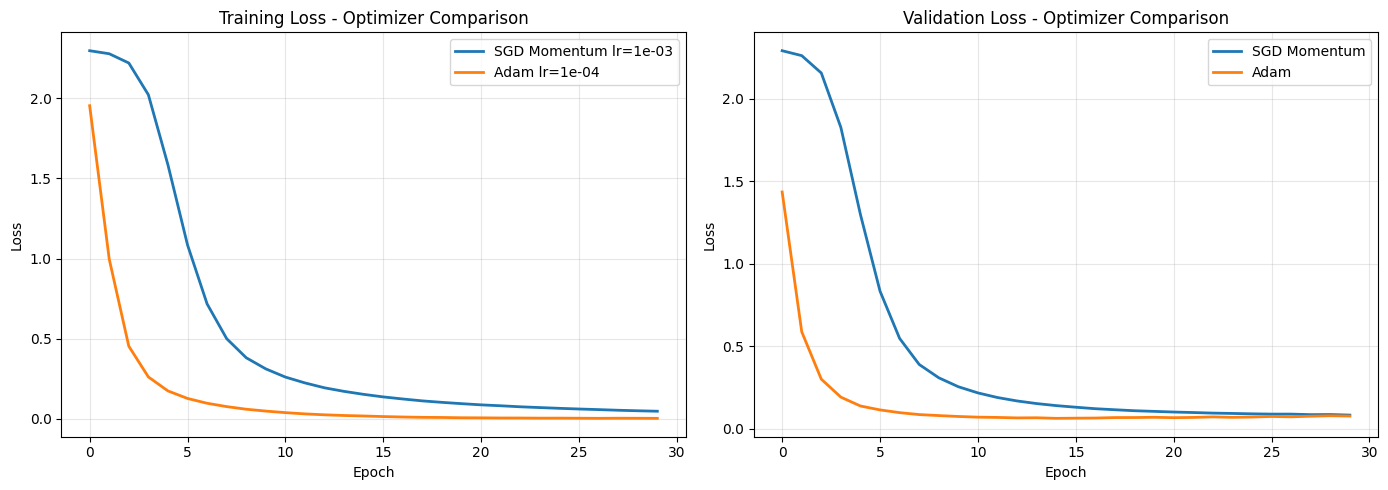


Final Results Summary
SGD Momentum    - Final Train: 0.0466, Final Val: 0.0819, Acc:0.9759 (97.59%)
Adam            - Final Train: 0.0022, Final Val: 0.0761, Acc:0.9808 (98.08%)


In [19]:
optimizer_sgd_config = {'learning_rate': 1e-3, 'momentum': 0.9}
optimizer_adam_config = {'learning_rate': 1e-4, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
criterion = ClassNLLCriterion()
n_epoch = 30

results_opt = {}

# Train with SGD Momentum
print("=" * 50)
print("Training with SGD Momentum")
print("=" * 50)

net_sgd = create_network(activation_class=ReLU, use_batchnorm=True)
train_loss, val_loss = train_network(
    net_sgd, criterion,
    X_train_flat, y_train_oh,
    X_val_flat, y_val_oh,
    sgd_momentum, optimizer_sgd_config,
    n_epoch=n_epoch
)
results_opt['SGD Momentum'] = {'train': train_loss, 'val': val_loss}
results_opt['SGD Momentum']['optimizer_config']=optimizer_sgd_config

net_sgd.evaluate()

X_test_flat = X_test.reshape(X_test.shape[0], -1)
test_predictions = net_sgd.forward(X_test_flat)

predicted_labels = np.argmax(test_predictions, axis=1)
test_accuracy = np.mean(predicted_labels == y_test)

results_opt['SGD Momentum']['test_accuracy'] = test_accuracy

# Train with Adam
print(f"\n{'='*50}")
print("Training with Adam")
print("=" * 50)

net_adam = create_network(activation_class=ReLU, use_batchnorm=True)
train_loss, val_loss = train_network(
    net_adam, criterion,
    X_train_flat, y_train_oh,
    X_val_flat, y_val_oh,
    adam_optimizer, optimizer_adam_config,
    n_epoch=n_epoch
)
results_opt['Adam'] = {'train': train_loss, 'val': val_loss}
results_opt['Adam']['optimizer_config']=optimizer_adam_config


net_adam.evaluate()

X_test_flat = X_test.reshape(X_test.shape[0], -1)
test_predictions = net_adam.forward(X_test_flat)

predicted_labels = np.argmax(test_predictions, axis=1)
test_accuracy = np.mean(predicted_labels == y_test)

results_opt['Adam']['test_accuracy'] = test_accuracy

# Plot comparison
plt.figure(figsize=(14, 5))

# Train loss
plt.subplot(1, 2, 1)
for name, data in results_opt.items():
    plt.plot(data['train'],
             label=f"{name} lr={data['optimizer_config']['learning_rate']:.0e}",
             linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss - Optimizer Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Validation loss
plt.subplot(1, 2, 2)
for name, data in results_opt.items():
    plt.plot(data['val'], label=name, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss - Optimizer Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final comparison
print("\n" + "=" * 50)
print("Final Results Summary")
print("=" * 50)
for name, data in results_opt.items():
    print(f"{name:15} - Final Train: {data['train'][-1]:.4f}"
          f", Final Val: {data['val'][-1]:.4f}"
          f", Acc:{data['test_accuracy']:.4f} ({data['test_accuracy']*100:.2f}%)"
          )



<font color=darkblue >
Adam с правильно подобранным lr (1e-4) сходится быстрее.
<br>
SGD Momentum с lr=1e-3 слишком медленно сходится - для достижения сравнимых результатов ему нужен либо больший lr (1e-2), либо больше эпох обучения.
</font>

### <font color=brown>Супер-классная модель на основе этого набора данных</font>

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

Training Final Model (ReLU + BatchNorm + Dropout + Adam with lr=1e-4)
Epoch 1/30, Train Loss: 2.0133, Val Loss: 1.5086
Epoch 2/30, Train Loss: 1.0955, Val Loss: 0.6588
Epoch 3/30, Train Loss: 0.5437, Val Loss: 0.3469
Epoch 4/30, Train Loss: 0.3467, Val Loss: 0.2329
Epoch 5/30, Train Loss: 0.2530, Val Loss: 0.1739
Epoch 6/30, Train Loss: 0.1997, Val Loss: 0.1400
Epoch 7/30, Train Loss: 0.1663, Val Loss: 0.1168
Epoch 8/30, Train Loss: 0.1411, Val Loss: 0.1029
Epoch 9/30, Train Loss: 0.1220, Val Loss: 0.0923
Epoch 10/30, Train Loss: 0.1090, Val Loss: 0.0858
Epoch 11/30, Train Loss: 0.0964, Val Loss: 0.0800
Epoch 12/30, Train Loss: 0.0863, Val Loss: 0.0768
Epoch 13/30, Train Loss: 0.0817, Val Loss: 0.0740
Epoch 14/30, Train Loss: 0.0716, Val Loss: 0.0700
Epoch 15/30, Train Loss: 0.0683, Val Loss: 0.0690
Epoch 16/30, Train Loss: 0.0627, Val Loss: 0.0666
Epoch 17/30, Train Loss: 0.0580, Val Loss: 0.0665
Epoch 18/30, Train Loss: 0.0531, Val Loss: 0.0663
Epoch 19/30, Train Loss: 0.0510, Val Lo

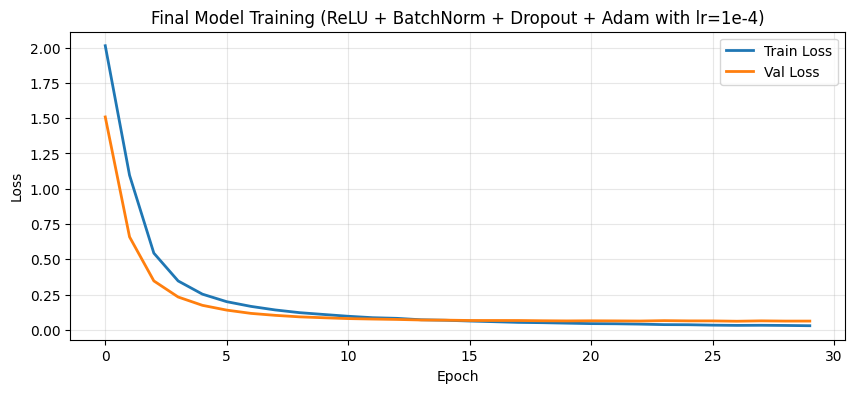

In [20]:
# Your code goes here. ################################################
print("=" * 50)
print("Training Final Model (ReLU + BatchNorm + Dropout + Adam with lr=1e-4)")
print("=" * 50)

# Создаём сеть со всеми регуляризациями
net_final = create_network(
    activation_class=ReLU,
    use_batchnorm=True,
    use_dropout=True,
    dropout_p=0.3
)

criterion = ClassNLLCriterion()
#optimizer_config = {'learning_rate': 1e-2, 'momentum': 0.9}
optimizer_config = {'learning_rate': 1e-4, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}

# Обучаем дольше для лучшего результата
train_loss, val_loss = train_network(
    net_final, criterion,
    X_train_flat, y_train_oh,
    X_val_flat, y_val_oh,
#    sgd_momentum, optimizer_config,
    adam_optimizer, optimizer_config,
    n_epoch=30
)

# График обучения
plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model Training (ReLU + BatchNorm + Dropout + Adam with lr=1e-4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



<font color=darkblue>
Что показывает график:

- Dropout работает - train loss выше val loss на первых эпохах (из-за dropout при обучении), это нормально;
- нет переобучения - val loss стабилен и не растёт;
- BatchNorm ускоряет - быстрая сходимость к хорошему результату уже к 10-й эпохе
</font>

Print here your accuracy on test set. It should be around 90%.

In [21]:
# Your answer goes here. ################################################

# отключаем Dropout для теста
net_final.evaluate()

X_test_flat = X_test.reshape(X_test.shape[0], -1)
test_predictions = net_final.forward(X_test_flat)

predicted_labels = np.argmax(test_predictions, axis=1)
custom_test_accuracy = np.mean(predicted_labels == y_test)

print("\n" + "=" * 50)
print("TEST RESULTS")
print("=" * 50)
print(f"Test Accuracy: {custom_test_accuracy:.4f} ({custom_test_accuracy*100:.2f}%)")


TEST RESULTS
Test Accuracy: 0.9814 (98.14%)


### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

Using device: cuda


/tmp/ipython-input-1522832459.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  y_train_tensor = torch.LongTensor(y_train)  # CrossEntropyLoss ожидает индексы, не one-hot


NetPyTorch(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)
Epoch 1/30, Train Loss: 0.3001, Val Loss: 0.1172
Epoch 2/30, Train Loss: 0.1516, Val Loss: 0.0894
Epoch 3/30, Train Loss: 0.1203, Val Loss: 0.0758
Epoch 4/30, Train Loss: 0.0992, Val Loss: 0.0695
Epoch 5/30, Train Loss: 0.0900, Val Loss: 0.0700
Epoch 6/30, Train Loss: 0.0793, Val Loss: 0.0637
Epoch 7/30, Train Loss: 0.0703, Val Loss: 0.0653
Epoch 8/30, Train Loss: 0.0663, Val Loss: 0.0629
Epoch 9/30, Train Loss: 0.0593, Val Loss: 0.0616
Epoch 10/30, Train Loss: 0.0544, Val Loss: 

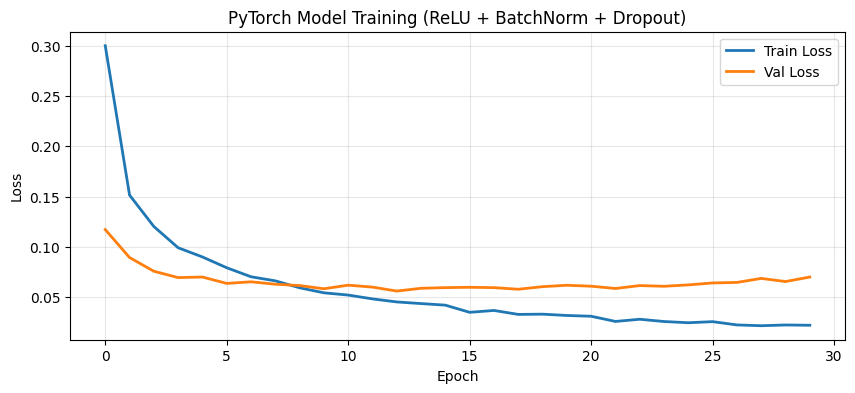


Comparison: Custom vs PyTorch
Custom Implementation: 98.14%
PyTorch Implementation: 98.49%


In [22]:
# Your beautiful code here.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# GPU ?
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_tensor = torch.FloatTensor(X_train_flat)
y_train_tensor = torch.LongTensor(y_train)  # CrossEntropyLoss ожидает индексы, не one-hot
X_val_tensor = torch.FloatTensor(X_val_flat)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_flat)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# такая же модель, как наша

class NetPyTorch(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10,
                 use_batchnorm=True, use_dropout=True, dropout_p=0.3):
        super(NetPyTorch, self).__init__()

        layers = []

        # Layer 1: Linear -> [BatchNorm] -> ReLU -> [Dropout]
        layers.append(nn.Linear(input_size, hidden_size))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # Layer 2: Linear -> [BatchNorm] -> ReLU -> [Dropout]
        layers.append(nn.Linear(hidden_size, hidden_size))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))
        # LogSoftmax не нужен - используем CrossEntropyLoss

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

model = NetPyTorch(use_batchnorm=True, use_dropout=True, dropout_p=0.3).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.04, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-8)

n_epoch = 30
train_losses = []
val_losses = []

for epoch in range(n_epoch):

    model.train()
    epoch_loss = []

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    train_loss = np.mean(epoch_loss)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        X_val_dev = X_val_tensor.to(device)
        y_val_dev = y_val_tensor.to(device)
        val_outputs = model(X_val_dev)
        val_loss = criterion(val_outputs, y_val_dev).item()
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

model.eval()
with torch.no_grad():
    X_test_dev = X_test_tensor.to(device)
    test_outputs = model(X_test_dev)
    _, predicted = torch.max(test_outputs, 1)
    test_accuracy = (predicted.cpu().numpy() == y_test).mean()

print("\n" + "=" * 50)
print("PyTorch TEST RESULTS")
print("=" * 50)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ==================================================
# График
# ==================================================

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch Model Training (ReLU + BatchNorm + Dropout)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==================================================
# Сравнение с нашей реализацией
# ==================================================

print("\n" + "=" * 50)
print("Comparison: Custom vs PyTorch")
print("=" * 50)
print(f"Custom Implementation: {custom_test_accuracy*100:.2f}%")
print(f"PyTorch Implementation: {test_accuracy*100:.2f}%")

### <font color=brown>Выводы</font>

## Conclusions

### 1. Сравнение функций активации
- **ReLU** и **LeakyReLU** показали лучшие результаты
- **ELU** чуть медленнее сходится, но стабильна
- **SoftPlus** - худший результат из-за вычислительной сложности exp/log

### 2. Эффект от BatchNormalization
- Ускоряет сходимость в **3-4 раза** (достигает val_loss 0.077 за 3 эпохи против 16 эпох без BatchNorm)
- Финальное качество (возможно) немного лучше, потому что val loss удалось уменьшить за 20 эпох сильнее

### 3. Сравнение SGD Momentum и Adam
- **Adam** быстрее сходится и проще в настройке
- **SGD Momentum** требует тщательного подбора lr, сходится медленнее при том же значении lr

### 4. Супер-классная модель, сравнение с реализацией на PyTorch

| модель         |оптимайзер    | accuracy   |
| ---------------|--------------|------------|
| Custom (NumPy) | Adam         | **98.11%** |
| PyTorch (CUDA) | SGD Momentum | **98.46%** |


- Dropout эффективно предотвращает переобучение (val loss стабильна, не растёт);
- наша модель получилась сопоставима с реализацией на PyTorch;
- использование графического процессора при обучении модели на PyTorch значительно ускоряет вычиления.

